In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('customer_behavior_dataset.csv')
df.drop(columns='CustomerID',inplace=True)
df

,Age,Gender,Membership,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,40,Male,NaN,40.58,Central,Mobile,Apparel,5,6.0,5,1,NaN,42.43,0,0,0,0.00
1,33,Male,NaN,53.20,West,Mobile,Apparel,3,9.0,2,0,25.95,0.00,206,0,0,0.00
2,42,Female,NaN,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.06,13.92,15,0,0,0.00
3,51,Female,NaN,45.95,East,Mobile,Sports,3,1.0,4,1,35.81,91.43,149,0,0,0.00
4,32,Male,Premium,45.32,East,Mobile,Apparel,11,11.1,7,3,5.00,37.75,6,1,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,Male,Premium,89.67,North,Mobile,Beauty,11,15.5,7,2,35.09,24.33,68,1,0,0.00
996,54,Male,NaN,97.17,Central,Mobile,Electronics,1,2.2,5,0,155.15,0.00,14,0,0,0.00
997,42,Female,Basic,33.47,South,Mobile,Apparel,6,4.3,8,6,34.29,298.47,2,0,0,0.00
998,28,Male,Premium,100.57,Central,Mobile,Electronics,7,16.9,8,3,118.26,411.34,9,1,1,57.64


In [3]:
x=df.drop(columns='Next_Month_Spend_USD')
y=df.Next_Month_Spend_USD

In [4]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [5]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

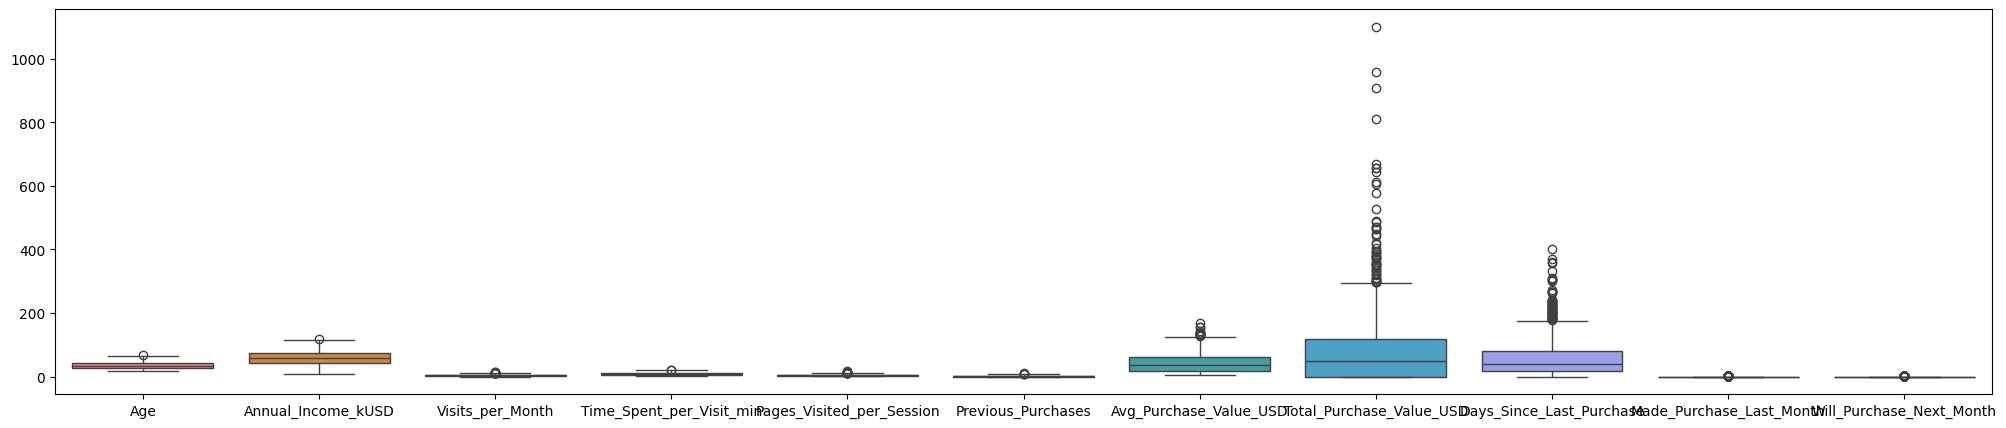

In [6]:
plt.figure(figsize=(25,5))
sns.boxplot(data=xtrain[num_cols])
plt.show()

In [9]:
preprocessing=ColumnTransformer(
    transformers=[
        ('standard_scaler', StandardScaler(),['Age', 'Annual_Income_kUSD', 'Visits_per_Month',
       'Time_Spent_per_Visit_min', 'Pages_Visited_per_Session',
       'Previous_Purchases','Made_Purchase_Last_Month', 'Will_Purchase_Next_Month']),
       ('robust_scaler',RobustScaler(), ['Avg_Purchase_Value_USD',
       'Total_Purchase_Value_USD', 'Days_Since_Last_Purchase'] )
    ],
    remainder='passthrough'
)

In [10]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ]
)